# Lab 4 — The Evaluation Harness
**SDA-AIE-111 · Day 3 · Hour 3 · 50 minutes · pairs**

**Objective.** Deliver a cross-validated comparison of all models so far on **shared folds**; tune the threshold to the voucher budget; produce a learning-curve verdict and two error-analysis findings with proposed fixes.

**The rule this lab installs:** every number on the scoreboard comes from `evaluate()` on the shared `CV` object, or it does not go on the scoreboard.


In [1]:
# --- Course setup (identical in every lab) -----------------------------------
import sys, warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")
RANDOM_STATE = 42

def find_repo_root() -> Path:
    """Locate the course repo root by looking for data/manafeth_customers.parquet."""
    for cand in [Path.cwd(), *Path.cwd().parents]:
        if (cand / "data" / "manafeth_customers.parquet").exists():
            return cand
    raise FileNotFoundError(
        "Course data not found — copy the Manafeth data package files into <repo>/data/")

ROOT = find_repo_root()
DATA = ROOT / "data"
sys.path.insert(0, str(ROOT / "src"))
print("repo root:", ROOT)

repo root: /home/claude/amlf/repo


In [2]:
from sklearn.model_selection import train_test_split
from manafeth.features import (build_preprocessor, build_feature_table,
                               MODEL_NUM_COLS, CAT_COLS, LEAKY)
from manafeth.evaluation import CV, evaluate, recall_at_budget, precision_at_budget

customers = pd.read_parquet(DATA / "manafeth_customers.parquet")
orders = pd.read_parquet(DATA / "manafeth_orders.parquet")
full = build_feature_table(customers, orders, pd.Timestamp("2025-11-01"))

X_all = full.drop(columns=["churned_30d", "customer_id", *LEAKY])
y_all = full["churned_30d"]
X_train, X_test, y_train, y_test = train_test_split(
    X_all, y_all, test_size=0.20, stratify=y_all, random_state=RANDOM_STATE)
print("train:", X_train.shape, "| churn:", round(y_train.mean(), 3))

train: (38400, 22) | churn: 0.14


## Task 1 — The harness *(10 min)*

`src/manafeth/evaluation.py` defines `evaluate()`: one function, every model, same folds. Comparisons stay legal. Run it on dummy, logistic, and the depth-capped tree.


In [3]:
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.pipeline import Pipeline

def make_pipe(model):
    return Pipeline([("prep", build_preprocessor(MODEL_NUM_COLS, CAT_COLS)), ("clf", model)])

dummy_pipeline  = make_pipe(DummyClassifier(strategy="stratified", random_state=RANDOM_STATE))
logreg_pipeline = make_pipe(LogisticRegression(class_weight="balanced", max_iter=1000,
                                               random_state=RANDOM_STATE))
tree_pipeline   = make_pipe(DecisionTreeClassifier(max_depth=6, class_weight="balanced",
                                                   random_state=RANDOM_STATE))

results = pd.DataFrame([
    evaluate(dummy_pipeline,  X_train, y_train, "dummy"),
    evaluate(logreg_pipeline, X_train, y_train, "logreg+features"),
    evaluate(tree_pipeline,   X_train, y_train, "tree(depth=6)"),
])
print(results[["pr_auc_mean", "pr_auc_std"]])
print("\nThe honest claim is mean ± 1 std — overlapping intervals mean 'no daylight'.")

                 pr_auc_mean  pr_auc_std
dummy                  0.141       0.001
logreg+features        0.544       0.012
tree(depth=6)          0.462       0.011

The honest claim is mean ± 1 std — overlapping intervals mean 'no daylight'.


## Task 2 — The threshold is a policy *(10 min)*

Out-of-fold probabilities via `cross_val_predict` — every score is honest. The budget constraint (contact 20% of the base) picks the threshold, not the 0.5 default nobody chose.


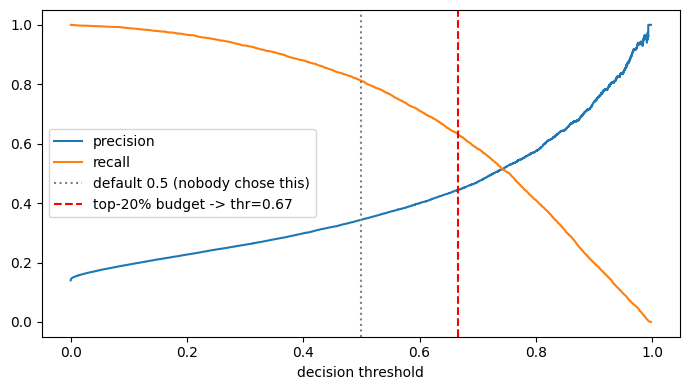

At budget threshold: precision 0.44, recall 0.63
At default 0.5:      precision 0.34, recall 0.81   (contact rate 33% — who approved that budget?)


In [4]:
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import precision_recall_curve

proba = cross_val_predict(logreg_pipeline, X_train, y_train, cv=CV,
                          method="predict_proba", n_jobs=-1)[:, 1]

prec, rec, thr = precision_recall_curve(y_train, proba)
budget_thr = np.quantile(proba, 0.80)      # the ACTUAL constraint: contact 20% of the base

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(thr, prec[:-1], label="precision")
ax.plot(thr, rec[:-1], label="recall")
ax.axvline(0.5, ls=":", color="grey", label="default 0.5 (nobody chose this)")
ax.axvline(budget_thr, ls="--", color="red", label=f"top-20% budget -> thr={budget_thr:.2f}")
ax.set_xlabel("decision threshold"); ax.legend(); plt.tight_layout(); plt.show()

flagged = proba >= budget_thr
print(f"At budget threshold: precision {y_train[flagged].mean():.2f}, "
      f"recall {y_train[flagged].sum() / y_train.sum():.2f}")
default = proba >= 0.5
print(f"At default 0.5:      precision {y_train[default].mean():.2f}, "
      f"recall {y_train[default].sum() / y_train.sum():.2f}"
      f"   (contact rate {default.mean():.0%} — who approved that budget?)")

## Task 3 — Learning curve: should we buy more data? *(10 min)*

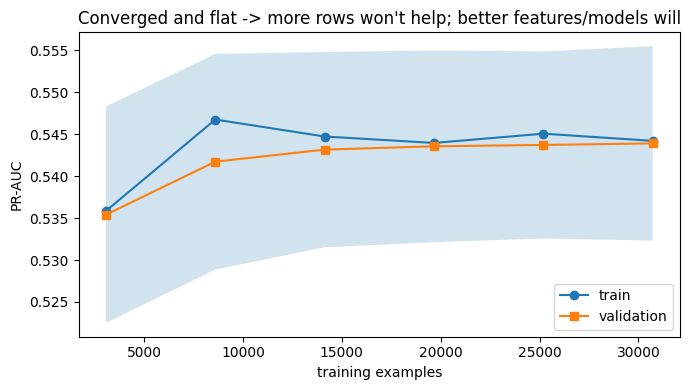

Verdict (one sentence): validation converged by ~8601 rows -> invest in features, not rows.


In [5]:
from sklearn.model_selection import learning_curve

sizes, tr, val = learning_curve(logreg_pipeline, X_train, y_train, cv=CV,
                                scoring="average_precision",
                                train_sizes=np.linspace(0.1, 1.0, 6), n_jobs=-1)
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(sizes, tr.mean(axis=1), marker="o", label="train")
ax.plot(sizes, val.mean(axis=1), marker="s", label="validation")
ax.fill_between(sizes, val.mean(1) - val.std(1), val.mean(1) + val.std(1), alpha=0.2)
ax.set_xlabel("training examples"); ax.set_ylabel("PR-AUC"); ax.legend()
ax.set_title("Converged and flat -> more rows won't help; better features/models will")
plt.tight_layout(); plt.show()
print("Verdict (one sentence): validation converged by ~%d rows -> invest in features, not rows."
      % int(sizes[np.argmax(val.mean(1) > val.mean(1)[-1] - 0.005)]))

## Task 4 — Slice-based error analysis *(15 min)*

Where does the model fail, and on whom? Slice recall at the budget threshold by city, tenure band, and device; then read the 20 worst false positives and 20 worst false negatives **row by row**. Findings must come with *proposed fixes* — error analysis that ends at numbers is spectating.


In [6]:
analysis = X_train.assign(y=y_train.values, proba=proba, flagged=(proba >= budget_thr))

def slice_recall(df, col):
    g = df[df["y"] == 1].groupby(col, observed=True)
    return (g["flagged"].mean().rename("recall")
            .to_frame().join(g.size().rename("churners")).round(2))

print(slice_recall(analysis, "city"), "\n")
tenure_band = pd.cut(analysis["tenure_months"], [0, 3, 12, 120],
                     labels=["new", "growing", "established"])
print(slice_recall(analysis, tenure_band), "\n")
print(slice_recall(analysis, "device"))

        recall  churners
city                    
Dammam    0.65      1099
Jeddah    0.61      1637
Riyadh    0.64      2640 

               recall  churners
tenure_months                  
new              0.64      1074
growing          0.68      2389
established      0.58      1913 

         recall  churners
device                   
Android    0.63      2852
iOS        0.64      2524


In [7]:
# The 20 worst false positives — read them aloud: who is the model wrongly flagging?
worst_fp = analysis[analysis["y"] == 0].nlargest(20, "proba")
cols = ["days_since_last_order", "orders_per_month", "ramadan_order_share",
        "basket_trend", "tenure_months", "proba"]
print(worst_fp[cols].round(2).to_string())
dormant = (worst_fp["basket_trend"] == 1.0) & (worst_fp["days_since_last_order"] > 60)
print(f"\nFPs that are long-silent with NO recent orders (basket_trend imputed 1.0): "
      f"{dormant.mean():.0%} of the top-20 "
      f"(population: {((analysis['basket_trend'] == 1.0) & (analysis['days_since_last_order'] > 60)).mean():.0%})")
# Reading: the model's loudest false alarms are dormant-looking customers who then
# DID order — the neutral basket_trend=1.0 imputation hides "no recent orders at all".

worst_fn = analysis[analysis["y"] == 1].nsmallest(20, "proba")
print("\nWorst false negatives (churned, scored safe):")
print(worst_fn[cols].round(2).to_string())

       days_since_last_order  orders_per_month  ramadan_order_share  basket_trend  tenure_months  proba
16638                    120              0.87                 0.00          1.00            7.5   0.99
13697                    120              1.14                 0.00          1.00            8.5   0.99
25306                    120              1.55                 0.00          1.00            3.8   0.99
25622                     68              0.71                 0.40          0.32           10.9   0.99
42824                    110              1.11                 0.00          1.00           14.8   0.99
22925                     96              0.59                 0.22          1.00           24.4   0.99
39449                    112              1.03                 0.00          1.00           13.0   0.99
22037                     98              1.72                 0.00          1.00            3.5   0.98
33150                     94              0.90                 0

**Findings (fill in — each with a proposed fix):**

1. Finding: … → Proposed fix: …
2. Finding: … → Proposed fix: …

**Commit:** `feat(lab4): CV harness, budget threshold, error-analysis findings`
